Data Loaded: (442, 11) samples
Training Optimizers...


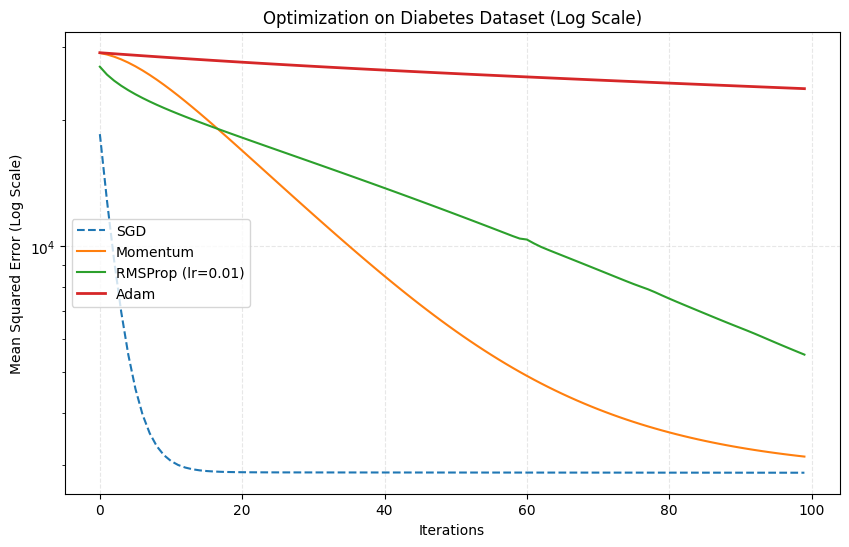


--- Final MSE Scores ---
SGD: 2875.62
Adam: 23791.83


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# 1. Data Setup
# ------------------------------------------
def load_data():
    """
    Loads Diabetes dataset, standardizes features, and adds bias term.
    Returns: X (Matrix), y (Vector)
    """
    diabetes = load_diabetes()
    X = diabetes.data
    y = diabetes.target

    # Standardize to make convergence smoother for our manual optimizers
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Add Intercept (Bias) term column of 1s
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]

    return X_b, y

# ------------------------------------------
# 2. Mathematical Primitives (Lecture 3 Part 1)
# ------------------------------------------

def compute_cost(X, y, theta):
    """
    Computes Mean Squared Error J(theta).
    Ref: Lecture 3, Eq 2 & 6.
    """
    m = len(y)
    # TODO: Calculate MSE cost
    # J = (1/m) * sum((h(x) - y)^2)
    # ==========================================
    predictions = X @ theta
    errors = predictions - y
    J = (1 / m) * np.sum(errors ** 2)
    return J
    # ==========================================

def compute_gradient(X, y, theta):
    """
    Computes the Gradient of J w.r.t theta.
    Ref: Lecture 3, Eq 8: dJ = (2/N) * X.T * (X.theta - y)
    """
    m = len(y)
    # TODO: Calculate gradient vector
    # ==========================================
    predictions = X @ theta
    errors = predictions - y
    gradient = (2 / m) * (X.T @ errors)
    return gradient
    # ==========================================

# ------------------------------------------
# 3. Optimizers
# ------------------------------------------

def sgd(X, y, learning_rate, n_iters):
    """
    Standard Gradient Descent (Batch Mode).
    """
    m, n = X.shape
    theta = np.zeros(n) # Initialize parameters
    cost_history = []

    for _ in range(n_iters):
        # 1. Calculate Gradient
        grad = compute_gradient(X, y, theta)

        # 2. Update Theta
        # theta = theta - learning_rate * grad
        # ==========================================
        theta = theta - learning_rate * grad
        pass
        # ==========================================
        # Track cost
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

def momentum(X, y, learning_rate, beta, n_iters):
    """
    Gradient Descent with Momentum.
    Ref: Lecture 3, Eq 40
    """
    m, n = X.shape
    theta = np.zeros(n)
    velocity = np.zeros(n) # Initialize velocity
    cost_history = []

    for _ in range(n_iters):
        grad = compute_gradient(X, y, theta)

        # TODO: Implement Momentum Update
        # 1. v = beta * v + grad
        # 2. theta = theta - lr * v
        # ==========================================
        velocity = beta * velocity + grad
        theta = theta - (learning_rate * velocity)
        pass
        # ==========================================

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

def rmsprop(X, y, learning_rate, beta, epsilon, n_iters):
    """
    RMSProp (Adaptive Learning Rate).
    Ref: Lecture 3, Eq 45 & 46
    """
    m, n = X.shape
    theta = np.zeros(n)
    v = np.zeros(n) # Squared gradient accumulator
    cost_history = []

    for _ in range(n_iters):
        grad = compute_gradient(X, y, theta)

        # TODO: Implement RMSProp Update
        # 1. v = beta * v + (1-beta) * grad^2
        # 2. theta = theta - (lr / (sqrt(v) + eps)) * grad
        # ==========================================
        v = beta * v + (1-beta) * (grad**2)
        theta = theta - (learning_rate/(np.sqrt(v)+ epsilon)) * grad
        pass
        # ==========================================

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

def adam(X, y, learning_rate, beta1, beta2, epsilon, n_iters):
    """
    Adam (Adaptive Moment Estimation).
    Ref: Lecture 3, Eq 50 & 51
    """
    m, n = X.shape
    theta = np.zeros(n)
    mt = np.zeros(n)
    vt = np.zeros(n)
    cost_history = []

    for t in range(1, n_iters + 1):
        grad = compute_gradient(X, y, theta)
        mt = beta1 * mt + (1 - beta1) * grad
        vt = beta2 * vt + (1 - beta2) * (grad ** 2)
        m_hat = mt / (1 - beta1 ** t)
        v_hat = vt / (1 - beta2 ** t)
        theta = theta - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# ------------------------------------------
# 4. Main Execution & Visualization
# ------------------------------------------
if __name__ == "__main__":
    X, y = load_data()
    print(f"Data Loaded: {X.shape} samples")

    epochs = 100
    lr = 0.1

    print("Training Optimizers...")

    _, hist_sgd = sgd(X, y, lr, epochs)

    _, hist_mom = momentum(X, y, 0.001, beta=0.9, n_iters=epochs)

    _, hist_rms = rmsprop(X, y, 1, beta=0.9, epsilon=1e-8, n_iters=epochs)

    _, hist_adam = adam(X, y, lr, beta1=0.9, beta2=0.999, epsilon=1e-8, n_iters=epochs)

    plt.figure(figsize=(10, 6))
    plt.plot(hist_sgd, label='SGD', linestyle='--')
    plt.plot(hist_mom, label='Momentum')
    plt.plot(hist_rms, label='RMSProp (lr=0.01)')
    plt.plot(hist_adam, label='Adam', linewidth=2)

    plt.title(f"Optimization on Diabetes Dataset (Log Scale)")
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error (Log Scale)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    print("\n--- Final MSE Scores ---")
    print(f"SGD: {hist_sgd[-1]:.2f}")
    print(f"Adam: {hist_adam[-1]:.2f}")

    #first thing we have are moving based on the assumption that we only have 1 global min normal convex
    #Bas now we are using batches so now we have many curves as a result many global minimum
    #So the graph will have steep places and plataues
    #Steep places have high gradient , plateuas have low gradient
    #So i'll need to make the opposite to avoid stucking , meaning steep places ill need something to lower its gradient , platues something to increase not to stop
    #beta is the thing affecting how the momentum shoots
    #That's where the momentum comes , it does this shift
    #Now we solved the gradient issue
    #Adagrad beyhel el moshkela (learning rate)
    #Now if we have learning rate issue based on features
    #If the features have big scale we'll have high gradient thats how it interprets it
    #So over time small scales will vanish
    #So to solve this we normalized the data
    #RMS Prop bey3mlk adap grad
    #Adam has momentum so it will converge slower
    #low zawdet el learning rate rms hay converge asra3 bas adam hayte2sar bel momentum
    #rms mafesh haga bet hold back , 3ayza RMS yewsal asra3
    #2k epochs to converge the rms and adam , rms will converge asra3
    #adam and rms will need learning rate a3la and epochs aktar mn SGD
    #instructor
    #ocislations betet2sar be ta2sor el learning rate low bel gradirent hatfre2 fel scale bas of momentum y3eny badal men 0-1 hateb2a men 0.001 le 0.01
    #leh hasalet oscillations 3shan el learning rate 3adet el 2/L
    #adap and rms are damping algorithms fa i should staart with high learning rate then yefdel ye2el low bad2et be olayel mesh haytehrak
    #adam and rms are not suitable for small data 3shan i divide 3ala arkam kebera fa el learning rate beyfdal ye2el lehad ma almost mesh hay learn aslun 
